## Latihan Mandiri - Machine Learning - Algoritma PCA
## Muhammad Rizqi Nurrohmat - 0110224001
## Dataset Breast Cancer - Pertemuan 12

### 1. Import Library

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from mpl_toolkits.mplot3d import Axes3D

### 2. Load Dataset

In [23]:
df = pd.read_csv('../data/data (1).csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


### 3. Eksplorasi Dataset Awal


In [24]:
# Melihat info dataset
df.info()

# Melihat statistik deskriptif dataset
df.describe()

# Mengecek missing value
df.isnull().sum()

# Menghapus kolom 'Unnamed: 32' karena seluruh nilainya kosong (missing value)
df = df.drop(columns=['Unnamed: 32'])

# Cek duplikasi
df.duplicated().sum()

# Distribusi kelas target
print("Nama Kelas Target:", df['diagnosis'].unique())
df['diagnosis'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

diagnosis
B    357
M    212
Name: count, dtype: int64

### 4. Fitur dan Label

In [25]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

print("Fitur (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Fitur (X) shape: (569, 31)
Target (y) shape: (569,)


### 5. Pembagian Data Latih dan Data Uji

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (455, 31)
X_test shape: (114, 31)


### 6. Standarrisasi Data

In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5]

array([[-2.43221088e-01,  5.18558727e-01,  8.91825791e-01,
         4.24631702e-01,  3.83925436e-01, -9.74743706e-01,
        -6.89771505e-01, -6.88586446e-01, -3.98175254e-01,
        -1.03915470e+00, -8.25056321e-01, -1.09317755e-01,
        -5.59755400e-02, -2.10096206e-01, -1.59132582e-02,
        -1.00518399e+00, -9.11941990e-01, -6.62815884e-01,
        -6.52561081e-01, -7.01889114e-01, -2.75393571e-01,
         5.79797697e-01,  1.31324246e+00,  4.66908134e-01,
         4.45982711e-01, -5.96154777e-01, -6.34722227e-01,
        -6.10227299e-01, -2.35743918e-01,  5.45663235e-02,
         2.18367276e-02],
       [ 4.08373367e-01, -5.16364088e-01, -1.63971029e+00,
        -5.41348716e-01, -5.42961327e-01,  4.76219058e-01,
        -6.31833818e-01, -6.04281166e-01, -3.03074908e-01,
         5.21543093e-01, -4.54522896e-01, -6.04377961e-01,
        -1.00104604e+00, -5.85429002e-01, -4.93453793e-01,
         4.03212009e-01, -7.68173276e-01, -4.79187222e-01,
         1.14508478e-01, -1.42

### 7. Penerapan Model SVM tanpa PCA

In [28]:
svm_no_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_no_pca.fit(X_train_scaled, y_train)

y_pred_no_pca = svm_no_pca.predict(X_test_scaled)

acc_no_pca = accuracy_score(y_test, y_pred_no_pca)
print("Akurasi tanpa PCA:", acc_no_pca)
print("Classification report tanpa PCA:\n", classification_report(y_test, y_pred_no_pca))
print(classification_report(y_test, y_pred_no_pca, target_names=['Bening', 'Malign']))

Akurasi tanpa PCA: 0.9649122807017544
Classification report tanpa PCA:
               precision    recall  f1-score   support

           B       0.96      0.99      0.97        72
           M       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

              precision    recall  f1-score   support

      Bening       0.96      0.99      0.97        72
      Malign       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



### 8. Penerapan PCA

In [29]:
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Shape X_train_pca:", X_train_pca.shape)
print("Shape X_test_pca:", X_test_pca.shape)

Shape X_train_pca: (455, 3)
Shape X_test_pca: (114, 3)


### 9. Menampilkan Varian Komponen PCA

In [30]:
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance)
print("Total Explained Variance (3 components):", np.sum(explained_variance))

Explained Variance Ratio: [0.43184634 0.17962517 0.0935514 ]
Total Explained Variance (3 components): 0.7050229101608617


### 10. Membangun Model SVM dengan PCA

In [31]:
svm_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_pca.fit(X_train_pca, y_train)

y_pred_pca = svm_pca.predict(X_test_pca)

acc_pca = accuracy_score(y_test, y_pred_pca)
print("Akurasi dengan PCA:", acc_pca)
print("Classification Report dengan PCA:\n", classification_report(y_test, y_pred_pca))
print(classification_report(y_test, y_pred_pca, target_names=['Bening', 'Malign']))

Akurasi dengan PCA: 0.956140350877193
Classification Report dengan PCA:
               precision    recall  f1-score   support

           B       0.94      1.00      0.97        72
           M       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114

              precision    recall  f1-score   support

      Bening       0.94      1.00      0.97        72
      Malign       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



### 11. Visualisasi PCA dalam Ruang 3 Dimensi

C:\Users\admin\AppData\Local\Temp\ipykernel_9632\4032027241.py:21: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  legend1 = ax.legend(


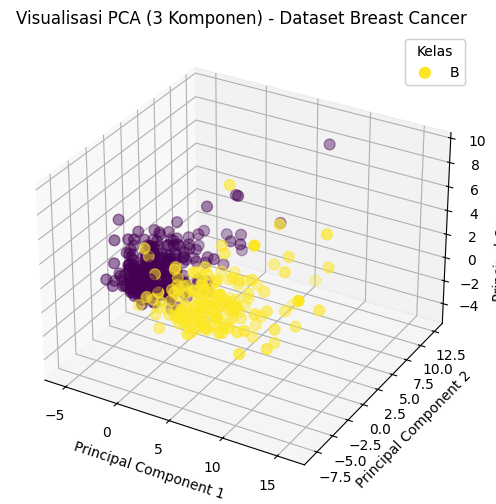

In [32]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    X_train_pca[:, 2],
    c=y_train_encoded,
    s=60
)

ax.set_title('Visualisasi PCA (3 Komponen) - Dataset Breast Cancer')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

labels = le.classes_
legend1 = ax.legend(
    *scatter.legend_elements(),
    title="Kelas",
    labels=labels
)
ax.add_artist(legend1)
plt.show()

### 12. Perbandingan Model SVM dengan dan tanpa PCA

In [34]:
# Membandingkan hasil model tanpa dan dengan PCA
comparison_df = pd.DataFrame({
    'Model': ['SVM tanpa PCA', 'SVM dengan PCA'],
    'Jumlah Fitur': [X_train.shape[1], X_train_pca.shape[1]],
    'Akurasi': [acc_no_pca, acc_pca],
    'Variasi Total PCA': [None, explained_variance.sum()]
})

comparison_df

,Model,Jumlah Fitur,Akurasi,Variasi Total PCA
0,SVM tanpa PCA,31,0.964912,NaN
1,SVM dengan PCA,3,0.956140,0.705023
